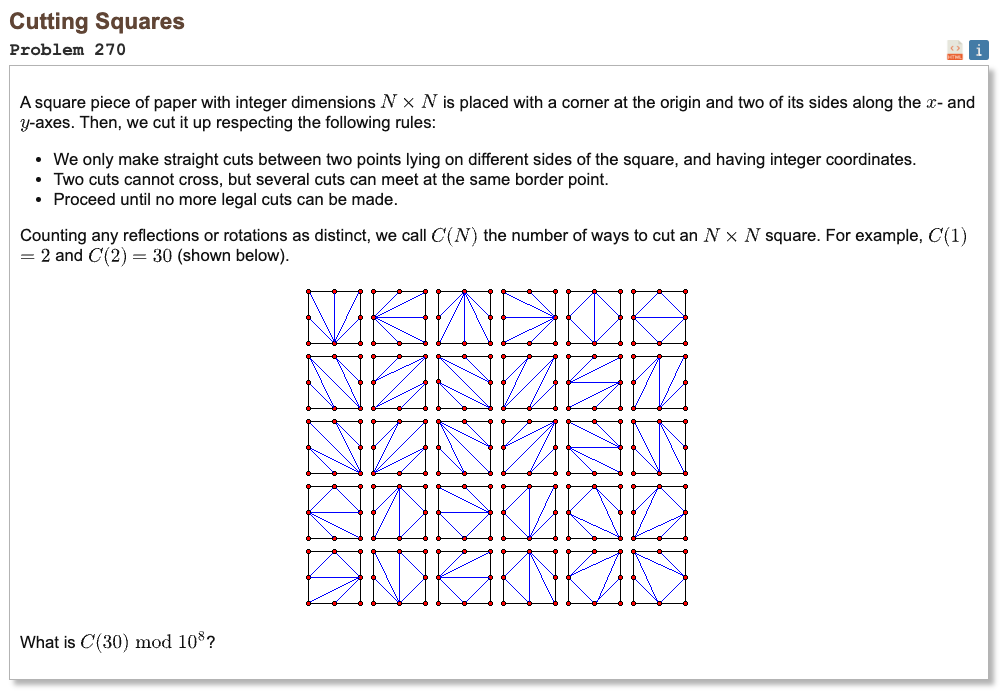

## Initial approach

* turn the square boundary into a cyclic list of 4N lattice points, then think of each cut as a chord in that boundary polygon
* each boundary point is tagged by which side or corner it belongs to, and a cut is legal only when the two endpoint tags do not share any side
* a finished cutting pattern is a maximal noncrossing chord set, so every face left behind must be irreducible, meaning you cannot add another legal chord inside that face
* use interval dp where dp[i][j] counts all maximal ways to dissect the subpolygon from boundary point i to boundary point j
* for one interval, focus on the single face touching the base edge (i,j), choose its boundary vertices in increasing order, and multiply the independent subproblems created between consecutive chosen vertices
* while building that face, keep a tiny bitmask state that says which boundary point types are still allowed for the next vertex, so irreducibility is enforced cheaply
* because the square boundary has only 8 possible point types, this state stays very small and Python is enough for N = 30  

In [1]:
def boundary_points(N):
    pts = []
    for x in range(N + 1):
        pts.append((x, 0))
    for y in range(1, N + 1):
        pts.append((N, y))
    for x in range(N - 1, -1, -1):
        pts.append((x, N))
    for y in range(N - 1, 0, -1):
        pts.append((0, y))
    return pts

def side_mask(pt, N):
    x, y = pt
    mask = 0
    if y == 0:
        mask |= 1
    if x == N:
        mask |= 2
    if y == N:
        mask |= 4
    if x == 0:
        mask |= 8
    return mask

def compute_C(N, mod=10**8):
    pts = boundary_points(N)
    n = len(pts)
    masks = [side_mask(p, N) for p in pts]

    type_map = {
        1: 0,
        2: 1,
        4: 2,
        8: 3,
        3: 4,
        6: 5,
        12: 6,
        9: 7
    }

    types = [type_map[m] for m in masks]
    masks_by_type = [0] * 8
    for m, t in type_map.items():
        masks_by_type[t] = m

    compat = [0] * 8
    for t in range(8):
        bit = 0
        for u in range(8):
            if masks_by_type[t] & masks_by_type[u]:
                bit |= 1 << u
        compat[t] = bit

    all_types = (1 << 8) - 1

    allowed = [[False] * n for _ in range(n)]
    for p in range(n):
        for q in range(p + 2, n):
            if masks[p] & masks[q]:
                continue
            allowed[p][q] = True

    dp = [[0] * n for _ in range(n)]
    for i in range(n - 1):
        dp[i][i + 1] = 1

    for length in range(2, n):
        for i in range(n - length):
            j = i + length
            memo = {}

            def f(p, R):
                key = (p, R)
                if key in memo:
                    return memo[key]

                total = 0
                for q in range(p + 1, j + 1):
                    if p == i and q == j:
                        continue
                    if ((R >> types[q]) & 1) == 0:
                        continue
                    if q != p + 1 and not allowed[p][q]:
                        continue
                    if p != i and q != j and (masks[q] & masks[i]) == 0:
                        continue
                    if q != j and p != i and (masks[p] & masks[j]) == 0:
                        continue

                    ways = dp[p][q]
                    if ways == 0:
                        continue

                    if q == j:
                        total += ways
                    else:
                        next_R = R if p == i else (R & compat[types[p]])
                        total += ways * f(q, next_R)

                memo[key] = total % mod
                return memo[key]

            dp[i][j] = f(i, all_types) % mod

    return dp[0][n - 1] % mod

def solve():
    assert compute_C(1) == 2
    assert compute_C(2) == 30
    return compute_C(30)

In [2]:
%%time
result = solve()
print("Result:", result)

Result: 82282080
CPU times: user 446 ms, sys: 4.03 ms, total: 450 ms
Wall time: 466 ms
